In [28]:
import psycopg2
import sys
from sqlalchemy import create_engine
import geopandas as gpd
from sqlalchemy import text

In [2]:
# Database name that will be created in the lab session
DATABASE_NAME = "demo_cosc_6060_1"

In [3]:
## Function to return the string query for creating sqlalchemy engine of a database
def getEngineConnectionString(user='postgres', password='12345', dbname='postgres'):
    return "postgresql://" + user + ":" + password + "@localhost/" + dbname

In [4]:
## Function to return psycopg2 connection to a database
def getOpenConnection(user='postgres', password='12345', dbname='postgres'):
    return psycopg2.connect(database = dbname, user = user, host='localhost', password= password)

In [5]:
## Creates a database with a given name if it does not exist
def createDB(dbname='postgres'):
    """
    We create a DB by connecting to the default user and database of Postgres
    The function first checks if an existing database exists for a given name, else creates it.
    :return:None
    """
    # Connect to the default database
    con = getOpenConnection(dbname='postgres')
    con.set_isolation_level(psycopg2.extensions.ISOLATION_LEVEL_AUTOCOMMIT)
    cur = con.cursor()

    # Check if an existing database with the same name exists
    cur.execute('SELECT COUNT(*) FROM pg_catalog.pg_database WHERE datname=\'%s\'' % (dbname,))
    count = cur.fetchone()[0]
    if count == 0:
        cur.execute('CREATE DATABASE %s' % (dbname,))  # Create the database
        print("DATABASE " + dbname + " created")
    else:
        print("Database with the given name already exists")

    # Clean up
    cur.close()
    con.commit()
    con.close()

In [6]:
## Create a database with name lab_postgis1
createDB(DATABASE_NAME)

DATABASE demo_cosc_6060_1 created


In [7]:
## Create sqlalchemy engine for the created database which will used to load geopandas dataframe to the database
engine = create_engine(getEngineConnectionString(dbname = DATABASE_NAME))
con = engine.connect()
print("sqlalchemy engine created")

sqlalchemy engine created


In [8]:
## In order to work with spatial data in a postgresql database, we need to add postgis extension to the database
try:
    con.execute(text("CREATE EXTENSION IF NOT EXISTS postgis;")) # Add PostGIS extension
    con.commit()
    print("postgis extension created")
except Exception as e:
    print(e)

postgis extension created


In [9]:
## Load the airbnb shape file to a geopandas dataframe
gdf_airbnb = gpd.read_file("inputs/airbnb/airbnb_Chicago 2015.shp")

In [10]:
## Display the first 5 rows the geopandas dataframe
gdf_airbnb.head()

,community,shape_area,shape_len,AREAID,response_r,accept_r,rev_rating,price_pp,room_type,num_spots,...,crowded,dependency,without_hs,unemployed,income_pc,harship_in,num_crimes,num_theft,population,geometry
0,DOUGLAS,46004621.1581,31027.0545098,35,98.771429,94.514286,87.777778,78.157895,1.789474,38,...,1.8,30.7,14.3,18.2,23791,47,5013,1241,18238,"POLYGON ((-87.60914 41.84469, -87.60915 41.844..."
1,OAKLAND,16913961.0408,19565.5061533,36,99.200000,90.105263,88.812500,53.775000,1.850000,20,...,1.3,40.4,18.4,28.7,19252,78,1306,311,5918,"POLYGON ((-87.59215 41.81693, -87.59231 41.816..."
2,FULLER PARK,19916704.8692,None,37,68.000000,NaN,91.750000,84.000000,1.833333,6,...,3.2,44.9,26.6,33.9,10432,97,1764,383,2876,"POLYGON ((-87.6288 41.80189, -87.62879 41.8017..."
3,GRAND BOULEVARD,48492503.1554,28196.8371573,38,94.037037,83.615385,92.750000,119.533333,1.533333,30,...,3.3,39.5,15.9,24.3,23472,57,6416,1428,21929,"POLYGON ((-87.60671 41.81681, -87.6067 41.8165..."
4,KENWOOD,29071741.9283,23325.1679062,39,92.542857,88.142857,90.656250,77.991453,1.615385,39,...,2.4,35.4,11.3,15.7,35911,26,2713,654,17841,"POLYGON ((-87.59215 41.81693, -87.59215 41.816..."


In [11]:
# with engine.begin() as conn:
#    conn.execute(text("DROP TABLE IF EXISTS airbnb"))
    
## load the airbnb data from geopandas dataframe into the database, it will create a table named airbnb. Ignore the warnings
gdf_airbnb.to_postgis(name = "airbnb", con=engine)

In [12]:
## Load the grocery shape file to a geopandas dataframe and display first 5 rows
gdf_grocery = gpd.read_file("inputs/grocery/chicago_sup.shp")
gdf_grocery.head()

,OBJECTID,Ycoord,Xcoord,Status,Address,Chain,Category,geometry
0,16,41.973266,-87.657073,OPEN,"1051 W ARGYLE ST, CHICAGO, IL. 60640",VIET HOA PLAZA,None,MULTIPOINT ((1168268.672 1933554.35))
1,18,41.696367,-87.681315,OPEN,"10800 S WESTERN AVE, CHICAGO, IL. 60643-3226",COUNTY FAIR FOODS,None,MULTIPOINT ((1162302.618 1832900.224))
2,22,41.868634,-87.638638,OPEN,"1101 S CANAL ST, CHICAGO, IL. 60607-4932",WHOLE FOODS MARKET,None,MULTIPOINT ((1173317.042 1895425.426))
3,23,41.877590,-87.654953,OPEN,"1101 W JACKSON BLVD, CHICAGO, IL. 60607-2905",TARGET/SUPER,new,MULTIPOINT ((1168996.475 1898801.406))
4,27,41.737696,-87.625795,OPEN,"112 W 87TH ST, CHICAGO, IL. 60620-1318",FOOD 4 LESS,None,MULTIPOINT ((1176991.989 1847262.423))


In [13]:
## load the grocery data from geopandas dataframe into the database, it will create a table named airbnb. Ignore the warnings
gdf_grocery.to_postgis(name = "grocery", con=engine)

In [14]:
## Close the sqlalchemy connection object, because we will work with psycopg2 connection from now on.
if con:
    con.close()

In [15]:
## Get psycopg2 connection to the database
con = getOpenConnection(dbname = DATABASE_NAME)
print("Got psycopg2 connection to the created database")

Got psycopg2 connection to the created database


In [16]:
## Get the cursor for the database connection to execute queries
cur = con.cursor()

In [17]:
## Find the SRID of the airbnb geometries
cur.execute("select ST_SRID(geometry) from airbnb limit 1")
result = cur.fetchall()
print(result)

[(4326,)]


In [18]:
## Find the SRID of the grocery geometries
cur.execute("select ST_SRID(geometry) from grocery limit 1")
result = cur.fetchall()
print(result)

[(6312,)]


In [19]:
## Geometry SRIDs of two tables are different. So, transform one of them and store in a table
cur.execute("create table grocery_new as select ST_Transform(grocery.geometry, 4326) as geometry from grocery")

In [20]:
## Check how new geometry coordinates look like after the transformation
cur.execute("select ST_AsText(geometry) from grocery_new limit 3")
result = cur.fetchall()
print(result)

[('MULTIPOINT((46.06287193273509 48.29059554270251))',), ('MULTIPOINT((45.76229352543728 47.41709723022278))',), ('MULTIPOINT((46.04280440417514 47.94890669715196))',)]


In [21]:
## For each airbnb, find number of groceries that are within the distance 133.9 from the corresponsding airbnb
cur.execute("create table airbnb_grocery as select airbnb.geometry as geom1, count(grocery_new.geometry) as grocery_count from airbnb, grocery_new where ST_Distance(grocery_new.geometry, airbnb.geometry) < 133.9 group by airbnb.geometry")

In [22]:
## Check how the first row of the new joined table looks like
cur.execute("select ST_asText(geom1), grocery_count from airbnb_grocery limit 1")
results = cur.fetchall()
print(results)

[('POLYGON((-87.54397811710443 41.75515222351075,-87.54397819520638 41.75515108379244,-87.54397819522654 41.755151082146014,-87.5439781208446 41.75515099107323,-87.54397072108749 41.7551419471765,-87.54396057464398 41.75513219998073,-87.54395959372282 41.75513125771082,-87.54395952815949 41.75513119469042,-87.54395916863668 41.75513014719246,-87.54395330032276 41.75511303954939,-87.54395511728899 41.75510524259051,-87.54395794196572 41.75509312095864,-87.54395123697294 41.75507155494697,-87.54395024863652 41.75506837657382,-87.543950220419 41.755068286641475,-87.54393994938508 41.75505707368266,-87.54393827125023 41.7550544084186,-87.54393347809622 41.755046793545525,-87.54394067493368 41.7550247516862,-87.54395141101024 41.75501000652716,-87.54396458884327 41.754994050345225,-87.54396536150993 41.75499311518362,-87.54396664572232 41.75499185751428,-87.54398153464874 41.75497728194113,-87.54399007585336 41.75497033717892,-87.54399515733527 41.754966205700036,-87.54400587898151 41.75496

In [23]:
## Commit the created table, otherwise sqlalchemy engine will not find it
con.commit()

In [24]:
## Export the data of the created table to a geopandas dataframe so that we can visualize it
final_sql = "select geom1, grocery_count from airbnb_grocery"
dfJoined = gpd.read_postgis(final_sql, engine, geom_col = "geom1")

In [25]:
## Check first 5 rows of the dataframe
dfJoined.head()

,geom1,grocery_count
0,"POLYGON ((-87.54398 41.75515, -87.54398 41.755...",148
1,"POLYGON ((-87.52462 41.6918, -87.52501 41.6918...",148
2,"POLYGON ((-87.54568 41.72282, -87.54559 41.722...",148
3,"POLYGON ((-87.60157 41.68621, -87.60168 41.686...",148
4,"POLYGON ((-87.60449 41.72255, -87.60449 41.722...",146


<Axes: >

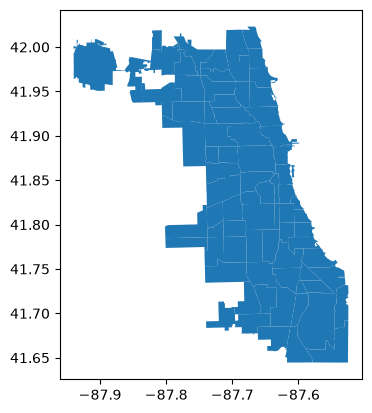

In [26]:
## Plot the geopandas dataframe without any attribute
dfJoined.plot()

<Axes: >

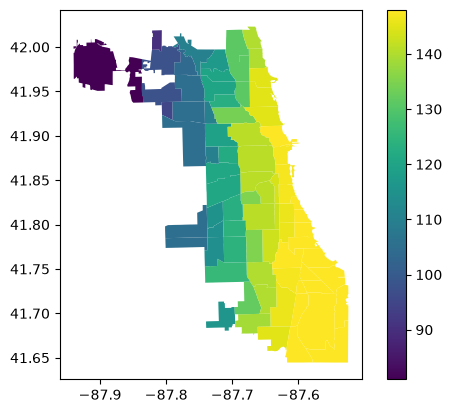

In [27]:
## Show color in airbnb zones based on the number of grocery shops
dfJoined.plot(column = "grocery_count", legend = True)